# Map Comparison Benchmark (binary-only)

Compares 4 sensors of varying noise level against a perfect-interpreter reference, using both full-raster pixel-level scoring (`src/map_comparison.py`) and the existing window-based sampling approaches (A–D). Config: `interpreter/experiments/configs/map_comparison_baseline.json`.

In [1]:
import sys, os, json

def find_project_root(marker='.git', start=None):
    """Walk upward from `start` (default: cwd) until `marker` is found.

    Jupyter kernel CWD for this notebook varies by machine/VS Code settings
    (sometimes the repo root, sometimes interpreter/notebooks/) — searching
    for a marker that only exists at the true root makes PROJ_ROOT immune
    to that.
    """
    path = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.exists(os.path.join(path, marker)):
            return path
        parent = os.path.dirname(path)
        if parent == path:
            raise RuntimeError(f"Could not find project root (marker: {marker!r}) above {start or os.getcwd()}")
        path = parent

PROJ_ROOT = find_project_root()
sys.path.insert(0, os.path.join(PROJ_ROOT, 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

from landscape_stack_collection import LandscapeStackCollection
from map_comparison import (
    perfect_reference_mask,
    pixel_level_metrics,
    pixel_level_metrics_for_collection,
    map_comparison_meta_analysis,
)

In [2]:
with open(os.path.join(PROJ_ROOT, 'interpreter/experiments/configs/map_comparison_baseline.json')) as f:
    cfg = json.load(f)

stack_cfg = cfg['landscape_stack_config']
train_exp_cfg = dict(cfg['training_experiment_config'])
val_exp_cfg = dict(cfg['validation_experiment_config'])
train_exp_cfg['patch_dir'] = os.path.join(PROJ_ROOT, train_exp_cfg['patch_dir'])
val_exp_cfg['patch_dir'] = os.path.join(PROJ_ROOT, val_exp_cfg['patch_dir'])

bc_cfg  = cfg['binary_classifier_config']
ws_cfg  = cfg['window_sample_config']

sensor_names = [s['name'] for s in stack_cfg['sensors']]
sensor_names

['Sensor_Clean', 'Sensor_Low', 'Sensor_Medium', 'Sensor_High']

## 1. Training collection + binary classifiers per sensor

In [3]:
train_collection = LandscapeStackCollection.from_config(
    stack_template_cfg=stack_cfg,
    experiment_cfg=train_exp_cfg,
)

train_collection.buildBinaryClassifier(
    sensor_names=bc_cfg['sensor_names'],
    n_strata=bc_cfg['n_strata'],
    samples_per_stratum=bc_cfg['samples_per_stratum'],
    sampling_seed=bc_cfg['sampling_seed'],
    fp_to_fn_ratio=bc_cfg['fp_to_fn_ratio'],
)
train_collection.applyBinaryClassifier(sensor_names=bc_cfg['sensor_names'])

/Users/rkennedy/Dropbox/caol/code/_claudecode/disturbance_uncertainty/src/disturbance_helper_functions.py:31: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-k * (x - x0)))


## 2. Validation collection (20 scenes, disjoint from training)

In [4]:
used_tifs = [s.base_landscape.tif_path for s in train_collection.stacks]

val_collection = LandscapeStackCollection.from_config(
    stack_template_cfg=stack_cfg,
    experiment_cfg=val_exp_cfg,
    exclude_tif_paths=used_tifs,
)

assert set(used_tifs).isdisjoint({s.base_landscape.tif_path for s in val_collection.stacks}), \
    'validation set overlaps training set'

val_collection.loadBinaryModel(train_collection.binary_models)
val_collection.applyBinaryClassifier(sensor_names=bc_cfg['sensor_names'])

/Users/rkennedy/Dropbox/caol/code/_claudecode/disturbance_uncertainty/src/disturbance_helper_functions.py:31: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-k * (x - x0)))


## 0. Validate the perfect-interpreter approximation

The extreme-slope detection/definition curves have no exact no-op (see config `notes`) — confirm empirically that the thresholded perfect-interpreter field agrees with ground truth almost everywhere before trusting it as a scoring reference.

In [5]:
for stack in val_collection.stacks[:3]:
    ref = perfect_reference_mask(stack)
    truth = stack.base_landscape.disturbed.astype(int)
    metrics = pixel_level_metrics(ref, truth)
    print(stack.stack_id, metrics)

DL_839e7ad0 {'agreement': np.float64(1.0), 'precision': np.float64(1.0), 'recall': np.float64(1.0), 'f1': np.float64(1.0), 'iou': np.float64(1.0), 'n_total': 48240}
DL_0ff4d232 {'agreement': np.float64(1.0), 'precision': np.float64(1.0), 'recall': np.float64(1.0), 'f1': np.float64(1.0), 'iou': np.float64(1.0), 'n_total': 45225}
DL_94dfc34b {'agreement': np.float64(1.0), 'precision': np.float64(1.0), 'recall': np.float64(1.0), 'f1': np.float64(1.0), 'iou': np.float64(1.0), 'n_total': 44844}


## 3. Pixel-level scoring (step 6)

In [6]:
pixel_df = pixel_level_metrics_for_collection(val_collection, sensor_names=bc_cfg['sensor_names'])
pixel_df.groupby('sensor_name')[['agreement', 'precision', 'recall', 'f1', 'iou']].mean()

,agreement,precision,recall,f1,iou
sensor_name,,,,,
Sensor_Clean,0.998576,0.934194,0.991164,0.959868,0.926382
Sensor_High,0.985994,0.655682,0.742046,0.692981,0.532725
Sensor_Low,0.991949,0.782797,0.884710,0.827418,0.710456
Sensor_Medium,0.989177,0.737397,0.791709,0.760478,0.616823


## 3b. Visual inspection — map panels

Two randomly chosen validation landscapes, each shown as a 2×2 panel:
**Truth (no noise) · Sensor_Low · Sensor_Medium · Sensor_High**

Visualizing stack indices: [15, 5]


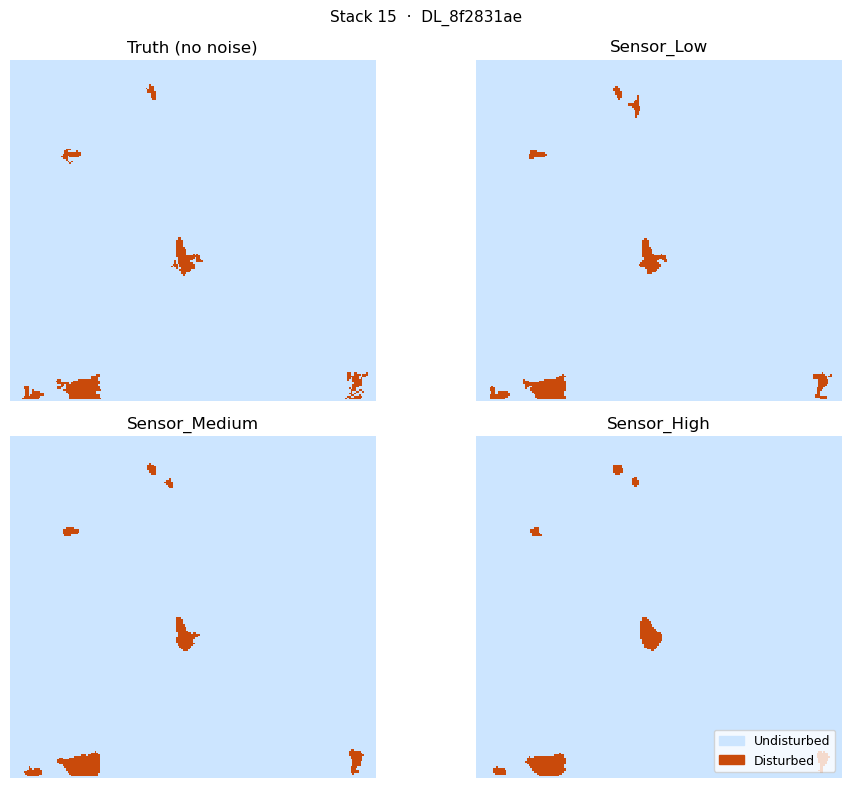

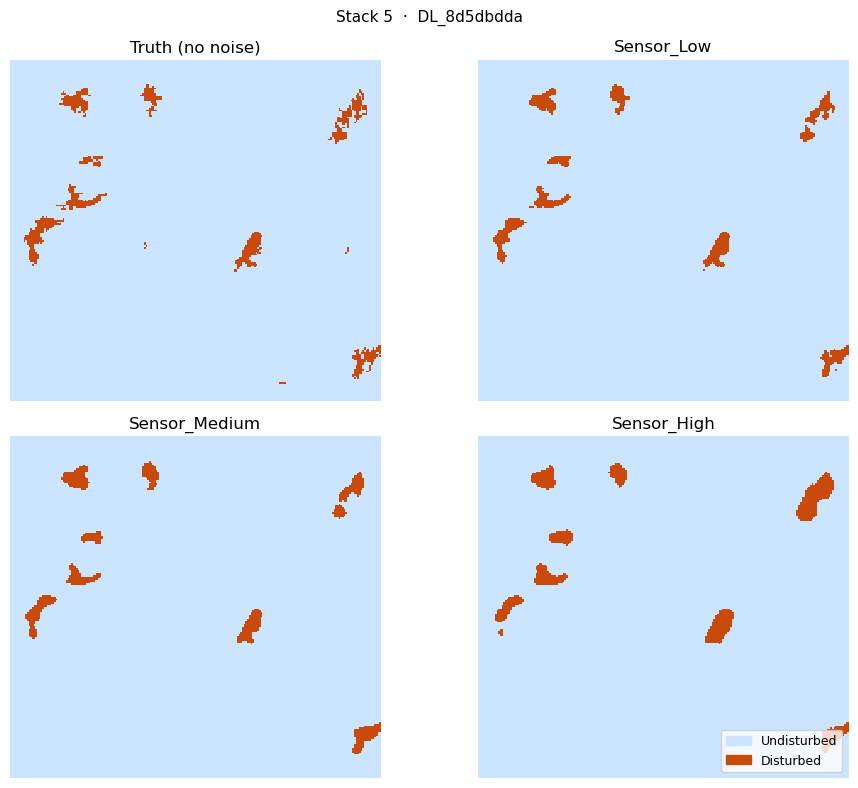

In [7]:
import random

# Reproducible random selection of 2 validation landscapes
_rng = random.Random(2024)
viz_indices = _rng.sample(range(len(val_collection.stacks)), 2)
print("Visualizing stack indices:", viz_indices)

CMAP_BINARY = ListedColormap(['#cce5ff', '#c94a0b'])  # undisturbed=pale blue, disturbed=brick red

for idx in viz_indices:
    stack = val_collection.stacks[idx]
    panels = [
        ('Truth (no noise)',  stack.base_landscape.disturbed.astype(int)),
        ('Sensor_Low',        stack.binary_class_by_sensor['Sensor_Low']),
        ('Sensor_Medium',     stack.binary_class_by_sensor['Sensor_Medium']),
        ('Sensor_High',       stack.binary_class_by_sensor['Sensor_High']),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    for ax, (title, arr) in zip(axes.flat, panels):
        ax.imshow(arr, cmap=CMAP_BINARY, vmin=0, vmax=1, interpolation='nearest')
        ax.set_title(title)
        ax.axis('off')

    legend_patches = [
        mpatches.Patch(color='#cce5ff', label='Undisturbed'),
        mpatches.Patch(color='#c94a0b', label='Disturbed'),
    ]
    axes[1, 1].legend(handles=legend_patches, loc='lower right', fontsize=9)
    fig.suptitle(f'Stack {idx}  ·  {stack.stack_id}', fontsize=11)
    fig.tight_layout()
    plt.show()

## 3c. Visual inspection — sampling overlays (A–D)

Same two landscapes, Sensor_Low as background. Windows placed with the same RSA seed as `window_sample_config`.

**Colour convention (A / B / C panels):**
Green = TP · Grey = TN · Red = FP · Blue = FN

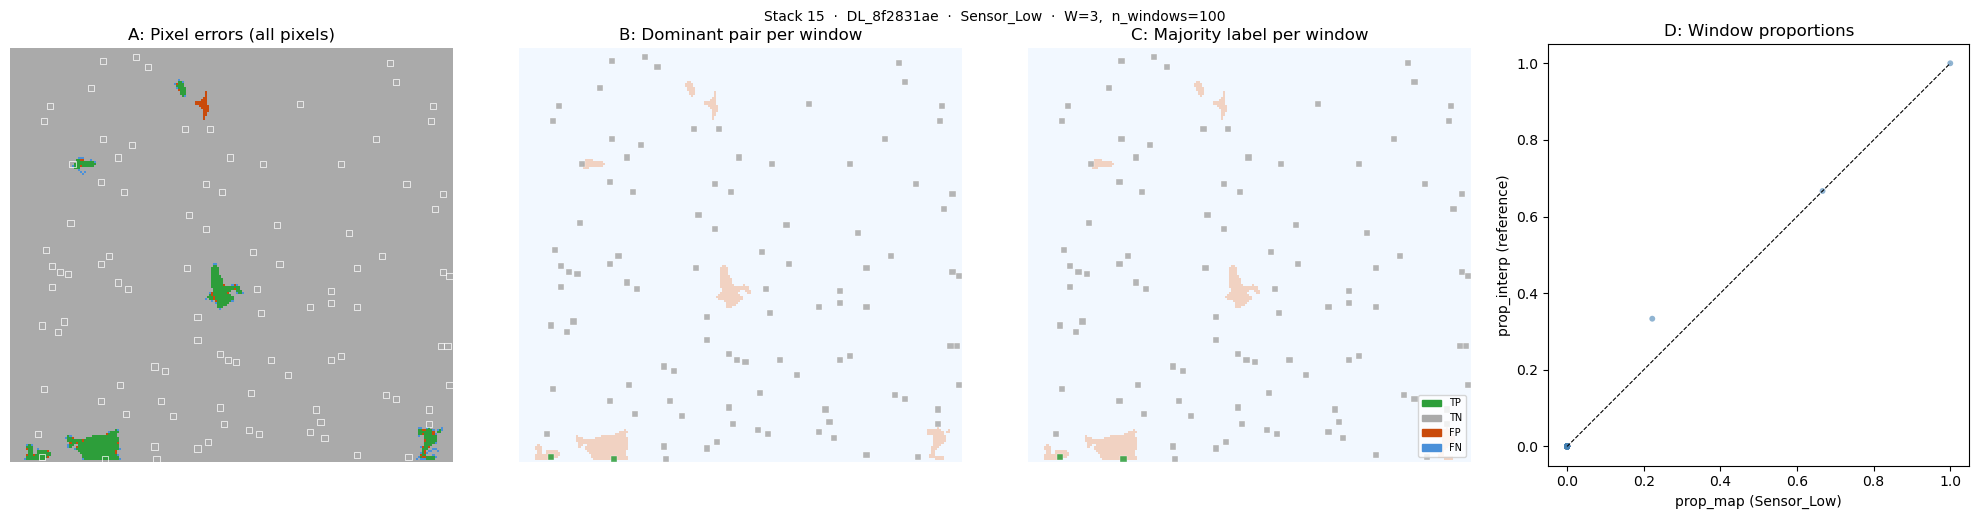

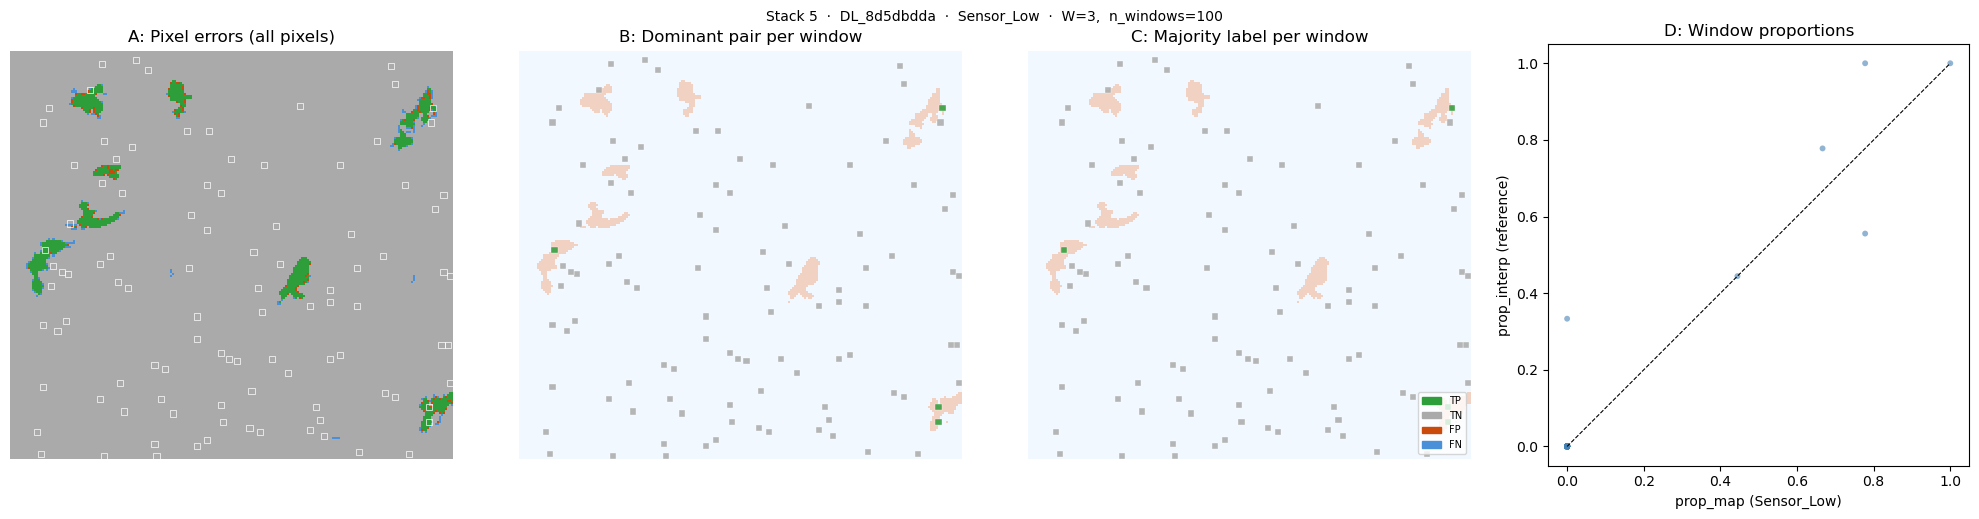

In [8]:
CMAP_ERROR  = ListedColormap(['#aaaaaa', '#4a90d9', '#c94a0b', '#2d9e3a'])  # TN, FN, FP, TP
ERROR_COLORS = {(0, 0): '#aaaaaa', (0, 1): '#4a90d9', (1, 0): '#c94a0b', (1, 1): '#2d9e3a'}
TIEBREAK = [(1, 1), (0, 0), (1, 0), (0, 1)]

def _error_arr(map_arr, ref_arr):
    """Encode per-pixel (map, ref) pair → 0=TN / 1=FN / 2=FP / 3=TP."""
    err = np.zeros_like(map_arr, dtype=int)
    err[(map_arr == 0) & (ref_arr == 0)] = 0
    err[(map_arr == 0) & (ref_arr == 1)] = 1
    err[(map_arr == 1) & (ref_arr == 0)] = 2
    err[(map_arr == 1) & (ref_arr == 1)] = 3
    return err

SENSOR_VIZ = 'Sensor_Low'
W = ws_cfg['window_size']

for idx in viz_indices:
    stack   = val_collection.stacks[idx]
    ref     = perfect_reference_mask(stack)
    smap    = stack.binary_class_by_sensor[SENSOR_VIZ]
    err     = _error_arr(smap, ref)

    windows = val_collection._extract_windows(
        sensor_name=SENSOR_VIZ,
        stack_indices=[idx],
        **ws_cfg,
    )

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(
        f'Stack {idx}  ·  {stack.stack_id}  ·  {SENSOR_VIZ}  ·  '
        f'W={W},  n_windows={len(windows)}',
        fontsize=10,
    )
    ax_A, ax_B, ax_C, ax_D = axes

    # ── Panel A: full error map + window outlines ─────────────────────────────
    ax_A.imshow(err, cmap=CMAP_ERROR, vmin=0, vmax=3, interpolation='nearest')
    for w in windows:
        r0 = w['row_center'] - W // 2
        c0 = w['col_center'] - W // 2
        ax_A.add_patch(mpatches.Rectangle(
            (c0 - .5, r0 - .5), W, W, lw=.5, ec='white', fc='none'))
    ax_A.set_title('A: Pixel errors (all pixels)')
    ax_A.axis('off')

    # ── Panels B and C: binary map background + coloured window blocks ────────
    for ax in (ax_B, ax_C):
        ax.imshow(smap, cmap=CMAP_BINARY, vmin=0, vmax=1,
                  interpolation='nearest', alpha=0.25)
        ax.axis('off')

    for w in windows:
        mp  = w['map_patch']      # (W, W) binary int
        ip  = w['interp_patch']   # (W, W) binary int
        r0  = w['row_center'] - W // 2
        c0  = w['col_center'] - W // 2

        # B: dominant pixel-pair (tiebreak order: TP > TN > FP > FN)
        counts   = {p: int(np.sum((mp == p[0]) & (ip == p[1]))) for p in TIEBREAK}
        dominant = max(TIEBREAK, key=lambda p: (counts[p], -TIEBREAK.index(p)))
        ax_B.add_patch(mpatches.Rectangle(
            (c0 - .5, r0 - .5), W, W, lw=.3, ec='white',
            fc=ERROR_COLORS[dominant], alpha=.85))

        # C: independent majority label per field
        maj_map = int(mp.mean() >= 0.5)
        maj_ref = int(ip.mean() >= 0.5)
        ax_C.add_patch(mpatches.Rectangle(
            (c0 - .5, r0 - .5), W, W, lw=.3, ec='white',
            fc=ERROR_COLORS[(maj_map, maj_ref)], alpha=.85))

    ax_B.set_title('B: Dominant pair per window')
    ax_C.set_title('C: Majority label per window')

    # ── Panel D: prop_map vs prop_interp scatter ──────────────────────────────
    props_map = [w['map_patch'].mean()    for w in windows]
    props_ref = [w['interp_patch'].mean() for w in windows]
    ax_D.scatter(props_map, props_ref, alpha=0.6, s=18, color='steelblue', edgecolors='none')
    ax_D.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax_D.set_xlabel(f'prop_map ({SENSOR_VIZ})')
    ax_D.set_ylabel('prop_interp (reference)')
    ax_D.set_xlim(-0.05, 1.05)
    ax_D.set_ylim(-0.05, 1.05)
    ax_D.set_aspect('equal')
    ax_D.set_title('D: Window proportions')

    # Shared error-type legend for A / B / C
    legend_patches = [
        mpatches.Patch(color='#2d9e3a', label='TP'),
        mpatches.Patch(color='#aaaaaa', label='TN'),
        mpatches.Patch(color='#c94a0b', label='FP'),
        mpatches.Patch(color='#4a90d9', label='FN'),
    ]
    ax_C.legend(handles=legend_patches, loc='lower right', fontsize=7)

    fig.tight_layout()
    plt.show()

## 4. Window-based sampling (step 7, unmodified A–D)

In [9]:
window_results = {}
for sensor_name in bc_cfg['sensor_names']:
    result = {}

    # Approaches A/B/C: (map_class, ref_class) schema -> confusion + Olofsson
    for method, window_fn in [
        ('A', val_collection.window_sample_A),
        ('B', val_collection.window_sample_B),
        ('C', val_collection.window_sample_C),
    ]:
        samples = window_fn(sensor_name=sensor_name, **ws_cfg)
        result[f'samples_{method}'] = samples
        result[f'confusion_{method}'] = val_collection.binary_confusion_from_samples(samples)
        result[f'olofsson_{method}'] = val_collection.olofsson_area_estimates(samples, sensor_name=sensor_name)

    # Approach D: (prop_map, prop_interp) scatter, no confusion matrix
    result['samples_D'] = val_collection.window_sample_D(sensor_name=sensor_name, **ws_cfg)

    window_results[sensor_name] = result

{name: {m: r[f'confusion_{m}']['n_ij'] for m in ['A', 'B', 'C']} for name, r in window_results.items()}

{'Sensor_Clean': {'A': array([[17585,     2],
         [   13,   358]]),
  'B': array([[1965,    0],
         [   1,   34]]),
  'C': array([[1965,    0],
         [   1,   34]])},
 'Sensor_Low': {'A': array([[17519,    46],
         [   79,   314]]),
  'B': array([[1960,    0],
         [   5,   35]]),
  'C': array([[1958,    1],
         [   8,   33]])},
 'Sensor_Medium': {'A': array([[17505,    77],
         [   93,   283]]),
  'B': array([[1956,    2],
         [   6,   36]]),
  'C': array([[1956,    3],
         [  10,   31]])},
 'Sensor_High': {'A': array([[17505,   106],
         [  109,   196]]),
  'B': array([[1961,    7],
         [   9,   23]]),
  'C': array([[1957,   11],
         [  12,   20]])}}

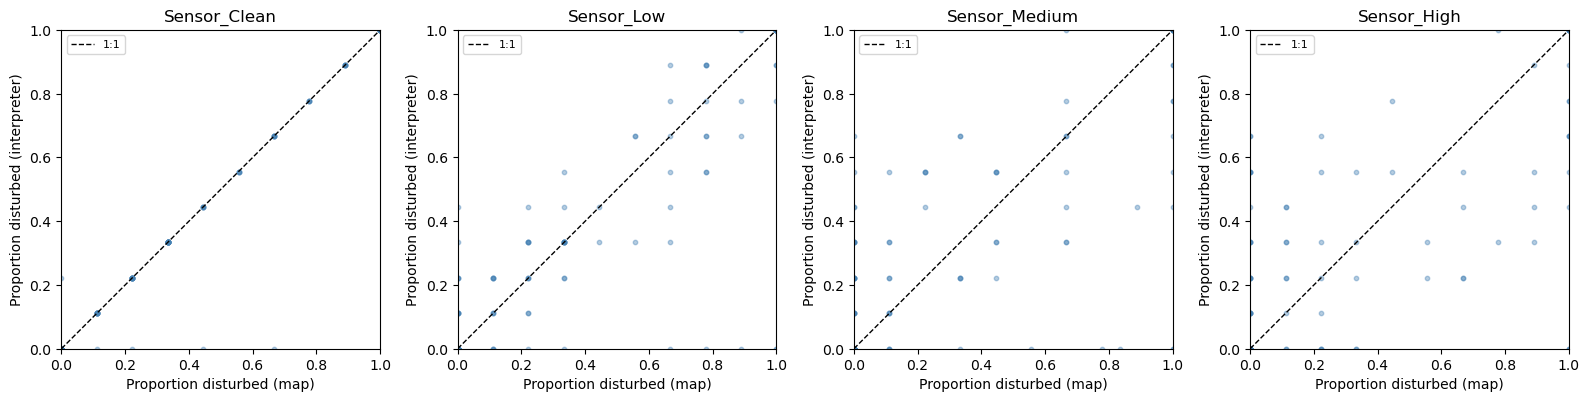

In [10]:
fig, axes = plt.subplots(1, len(bc_cfg['sensor_names']), figsize=(4 * len(bc_cfg['sensor_names']), 4))
for ax, sensor_name in zip(axes, bc_cfg['sensor_names']):
    val_collection.plot_window_D(window_results[sensor_name]['samples_D'], ax=ax, title=sensor_name)
fig.tight_layout()

## 5. Meta-analysis (step 8): pixel-level vs. sampling-based metric deltas

In [11]:
meta_df = map_comparison_meta_analysis(
    val_collection,
    sensor_names=bc_cfg['sensor_names'],
    window_fns={
        'A': val_collection.window_sample_A,
        'B': val_collection.window_sample_B,
        'C': val_collection.window_sample_C,
        'D': val_collection.window_sample_D,
    },
    window_kwargs=ws_cfg,
)
meta_df

,sensor_a,sensor_b,metric,pixel_delta,sampling_delta_A,sampling_delta_B,sampling_delta_C,sampling_delta_D
0,Sensor_Clean,Sensor_Low,agreement,0.006627,0.005916,0.002500,0.007000,NaN
1,Sensor_Clean,Sensor_Low,precision,0.151397,0.172496,0.100329,0.218750,NaN
2,Sensor_Clean,Sensor_Low,recall,0.106454,0.165563,0.029412,0.225806,NaN
3,Sensor_Clean,Sensor_Low,f1,0.132451,0.169367,0.067460,0.222222,NaN
4,Sensor_Clean,Sensor_Low,iou,0.215926,0.277078,0.122596,0.353365,NaN
5,Sensor_Clean,Sensor_Low,pearson_r,NaN,NaN,NaN,NaN,0.081355
6,Sensor_Clean,Sensor_Medium,agreement,0.009399,0.009656,0.004500,0.010000,NaN
7,Sensor_Clean,Sensor_Medium,precision,0.196796,0.260114,0.150568,0.302083,NaN
8,Sensor_Clean,Sensor_Medium,recall,0.199455,0.321192,0.129032,0.354839,NaN
9,Sensor_Clean,Sensor_Medium,f1,0.199390,0.290149,0.140377,0.328389,NaN
